In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


# 2D Toy example 

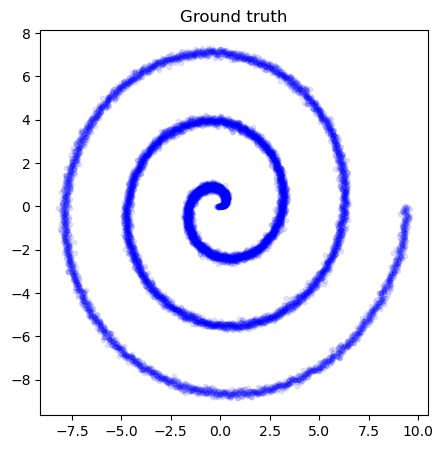

In [382]:
# 1. Spin around 3 times (3 * 2*pi)
theta = np.linspace(0, 3 * 2 * np.pi, 10000)

# Add your noise
noise = np.random.normal(0, 0.1, 10000)

# 2. Radius grows as theta grows. 
# Multiplying by 0.5 controls how tightly coiled the spiral is.
r = (0.5 * theta) + noise 

spiral_x = np.cos(theta) * r
spiral_y = np.sin(theta) * r

ground_truth = np.column_stack([spiral_x, spiral_y])

# CRITICAL FOR YOUR DRIFTING MODEL: 
# Because the spiral gets quite wide at the ends, always normalize it 
# so your neural network doesn't explode when calculating distances!
ground_truth = (ground_truth - np.mean(ground_truth, axis=0)) / np.std(ground_truth, axis=0)


plt.figure(figsize=(5, 5)) 
plt.title("Ground truth")
plt.scatter(spiral_x, spiral_y, s=10, alpha=0.1, color = 'blue')
plt.show()

ground_truth = np.array([list(pair) for pair in zip(spiral_x, spiral_y)])
ground_truth = torch.from_numpy(ground_truth).to(torch.float32).to(device)


In [10]:
# define the model architecture for f 
class neuralNet(nn.Module):
    def __init__(self):
        # Call the constructor of the parent class (nn.Module)
        super(neuralNet, self).__init__()

        self.input = nn.Linear(32, 258)
        self.initialRelu = nn.SiLU()
        self.layer1 = nn.Linear(258, 258)
        self.relu1 = nn.SiLU()
        self.layer2 = nn.Linear(258, 258)
        self.relu2 = nn.SiLU()
        #self.layer3 = nn.Linear(258, 258)
        #self.relu3 = nn.SiLU()
        self.output = nn.Linear(258, 2)

    def forward(self, v):
        " v is vector dim 2 (x, y)"
        v = self.input(v)
        v = self.initialRelu(v)
        v = self.layer1(v)
        v = self.relu1(v)
        v = self.layer2(v)
        v = self.relu2(v)
        #v = self.layer3(v)
        #v = self.relu3(v)
        v = self.output(v)
        return v
        

Note that I had not used the commented (# comment) column softmax. I only did the row. 
But sinkhorn drifting generative models, shows why including the normalization across the columns as well improves the training. 

Interestingly, the original paper's actual implementation (Algorithm 2, page 12) already goes a step further, applying softmax over both rows and columns and taking the geometric mean (A = sqrt(A_row * A_col)). As the Sinkhorn paper notes (page 2), that heuristic two-sided normalization was empirically observed to help — and the Sinkhorn formulation now explains why: it moves the coupling closer to the doubly-stochastic Sinkhorn solution.

In [5]:
def softmax(logits, dim):
    logits = logits - logits.max(dim=dim, keepdim=True).values
    exp = torch.exp(logits)
    return exp / exp.sum(dim=dim, keepdim=True)

def compute_V(y_pos, y_neg, T=0.25, eps=1e-8):
    N = y_neg.shape[0]
    points = torch.cat([y_neg, y_pos],dim=0).to(torch.float32)

    dist = torch.cdist(y_neg, points)
    dist[:, :N] += torch.eye(N, device=dist.device) * 1e6 # So that the point you are standing doesn't influence, really important

    logits = -dist/T # this is log(k(x,y)) for every pair
    A_row = softmax(logits, dim=1)  # Equivalent to Z normalization, Zq and Zp at the same time
    #A_col = softmax(logits, dim=0)  # normalize each column (target) across particles
    #A = torch.sqrt(A_row * A_col)
    A = A_row
    
    A_neg = A[:, :N]
    A_pos = A[:, N:]

    W_pos = A_pos * A_neg.sum(axis=1, keepdims=True) # k(x,y+) scaled by total neg mass
    W_neg = A_neg * A_pos.sum(axis=1, keepdims=True) # k(x,y-) scaled by total pos mass

    drift_pos = W_pos @ y_pos
    drift_neg = W_neg @ y_neg
    V = drift_pos - drift_neg
    
    return V

def loss_function(generated, y_pos): 
    with torch.no_grad():
        V = compute_V(y_pos, generated)
        frozen_targets = (generated + V).detach().clone()
    return mse(generated, frozen_targets)

In [6]:
# train and keep record of some iterations to graph
f = neuralNet()
mse = nn.MSELoss()
optimizer = optim.AdamW(f.parameters(), lr=0.001)
gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)

def training_loop(num_epochs, batch_size = 1000):
    f.to(device)
    train_losses = []
    print("Training stared")
    special_iterations =  [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]
    q_evolution = []
    
    for epoch in range(num_epochs+1):
        epoch_loss = 0.0
        f.train()
        optimizer.zero_grad()

        noise_indices = np.random.choice(10000, batch_size, replace=False)
        real_indices = np.random.choice(len(ground_truth), batch_size, replace=False)
        gaussian_batch = gaussian[noise_indices]
        truth_batch = ground_truth[real_indices]

        generated = f(gaussian_batch)
        loss =  loss_function(generated, truth_batch) 
        loss.backward()
        optimizer.step()
        
        epoch_loss = loss.item()
        train_losses.append(epoch_loss)
        if epoch in special_iterations:
            q_evolution.append(generated.detach().cpu().numpy())
        if epoch % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Loss: {epoch_loss:.6f}")
            
    print("Finished")
    return f, train_losses, q_evolution
    

In [392]:
f_trained, losses, evolution = training_loop(5000)

Training stared
Epoch [0/5000], Loss: 0.000073
Epoch [100/5000], Loss: 0.017266
Epoch [200/5000], Loss: 0.014772
Epoch [300/5000], Loss: 0.011696
Epoch [400/5000], Loss: 0.011665
Epoch [500/5000], Loss: 0.009728
Epoch [600/5000], Loss: 0.008915
Epoch [700/5000], Loss: 0.008722
Epoch [800/5000], Loss: 0.006942
Epoch [900/5000], Loss: 0.007278
Epoch [1000/5000], Loss: 0.006348
Epoch [1100/5000], Loss: 0.005933
Epoch [1200/5000], Loss: 0.005442
Epoch [1300/5000], Loss: 0.005460
Epoch [1400/5000], Loss: 0.004619
Epoch [1500/5000], Loss: 0.004887
Epoch [1600/5000], Loss: 0.003977
Epoch [1700/5000], Loss: 0.003550
Epoch [1800/5000], Loss: 0.004461
Epoch [1900/5000], Loss: 0.003711
Epoch [2000/5000], Loss: 0.002814
Epoch [2100/5000], Loss: 0.003037
Epoch [2200/5000], Loss: 0.003405
Epoch [2300/5000], Loss: 0.002687
Epoch [2400/5000], Loss: 0.002454
Epoch [2500/5000], Loss: 0.002687
Epoch [2600/5000], Loss: 0.002634
Epoch [2700/5000], Loss: 0.002617
Epoch [2800/5000], Loss: 0.002124
Epoch [290

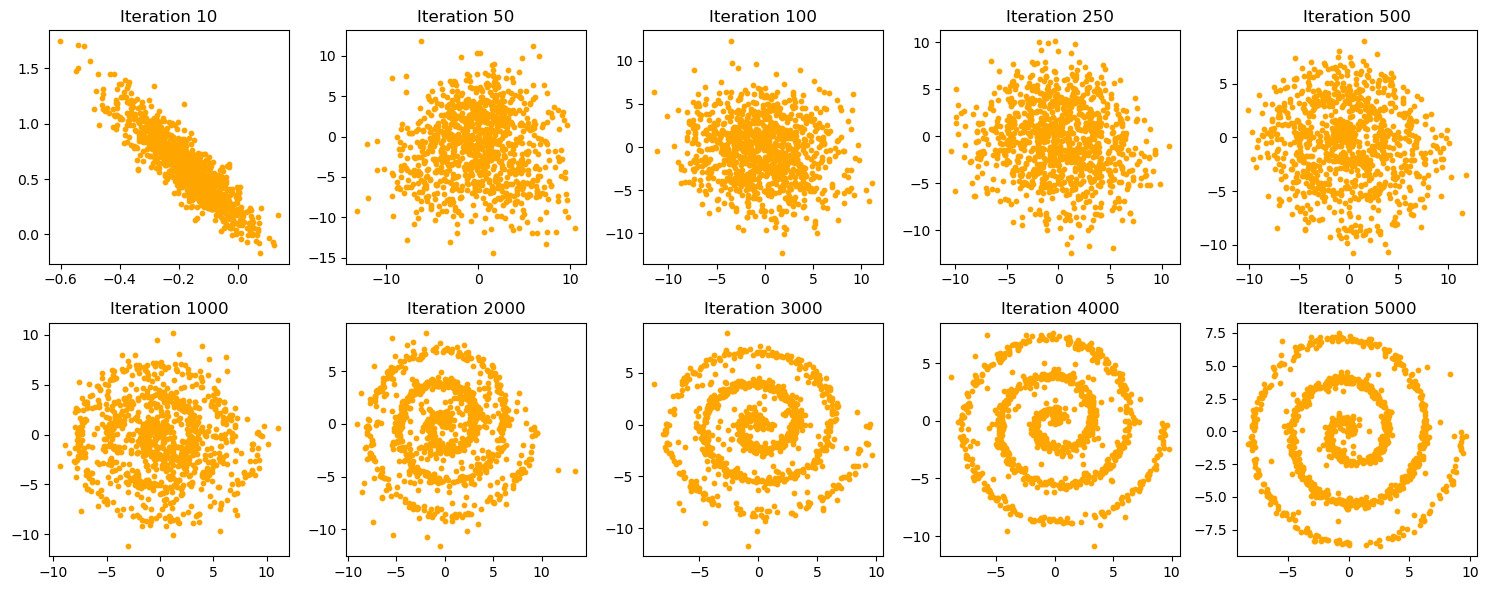

In [393]:
its = [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]

fig, axes = plt.subplots(2, 5, figsize=(15, 6)) 

# Flatten the 2D axes array to 1D to make iteration simple
axes = axes.flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")

plt.tight_layout()

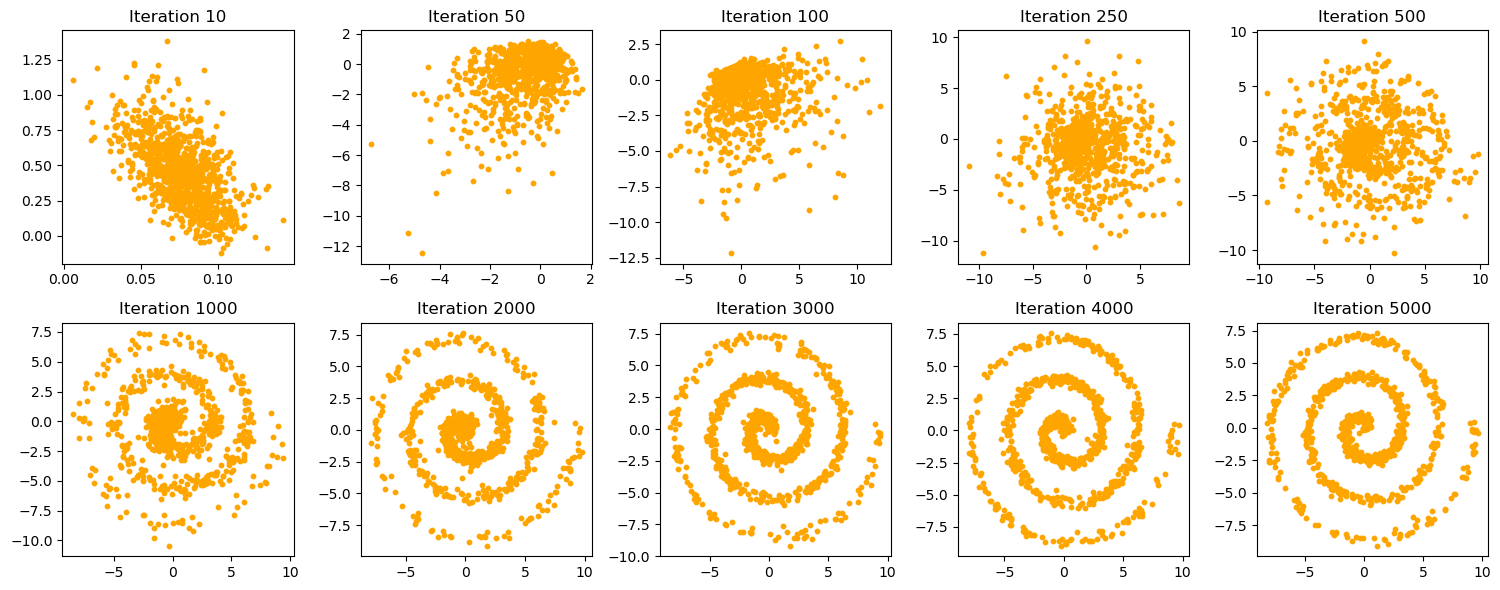

In [388]:

its = [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]

fig, axes = plt.subplots(2, 5, figsize=(15, 6)) 

# Flatten the 2D axes array to 1D to make iteration simple
axes = axes.flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")

plt.tight_layout()

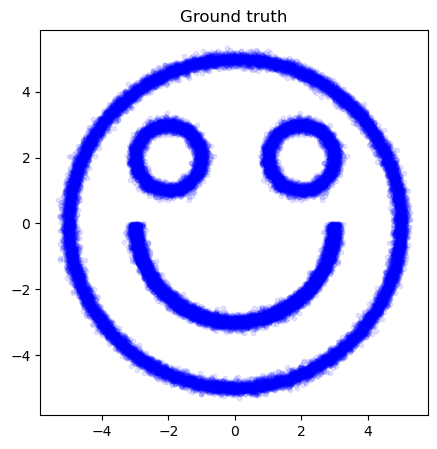

In [7]:
# Define the ground truth, target distribution
# theta values from 0 to 2pi for eyes and face
theta_eyes = np.linspace(0, 2 * np.pi, 5000)
theta_face = np.linspace(0, 2 * np.pi, 20000)
# phi values from 0 to pi for smile
phi = np.linspace(0, np.pi, 10000) 
# define radius with noise
mean = 0
std = 0.1
noise_eyes = np.random.normal(mean, std, len(theta_eyes))
noise_face = np.random.normal(mean, std, len(theta_face))
noise_smile = np.random.normal(mean, std, len(phi))
eyes_r = 1 + noise_eyes
face_r = 5 + noise_face
smile_r = 3 + noise_smile
# parametrization
face_x = np.cos(theta_face) * face_r
face_y = np.sin(theta_face) * face_r
leftEye_x = (np.cos(theta_eyes) * eyes_r) - 2 
leftEye_y = (np.sin(theta_eyes) * eyes_r) + 2
rightEye_x = (np.cos(theta_eyes) * eyes_r) + 2
rightEye_y = (np.sin(theta_eyes) * eyes_r) +2
smile_x = np.cos(phi) * smile_r
smile_y = np.sin(phi) * -smile_r

happyFace_x = np.concatenate([
    face_x,
    leftEye_x,
    rightEye_x,
    smile_x
])

happyFace_y = np.concatenate([
    face_y,
    leftEye_y,
    rightEye_y,
    smile_y
])

plt.figure(figsize=(5, 5)) 
plt.title("Ground truth")
plt.scatter(happyFace_x, happyFace_y, s=10, alpha=0.1, color = 'blue')
plt.show()

ground_truth = np.array([list(pair) for pair in zip(happyFace_x, happyFace_y)])
ground_truth = torch.from_numpy(ground_truth).to(torch.float32).to(device)
ground_truth = (ground_truth - torch.min(ground_truth)) / (torch.max(ground_truth) - torch.min(ground_truth))



In [11]:
f_trained, losses, evolution = training_loop(5000)

Training stared
Epoch [0/5000], Loss: 0.000258
Epoch [100/5000], Loss: 0.000181
Epoch [200/5000], Loss: 0.000195
Epoch [300/5000], Loss: 0.000222
Epoch [400/5000], Loss: 0.000204
Epoch [500/5000], Loss: 0.000201
Epoch [600/5000], Loss: 0.000161
Epoch [700/5000], Loss: 0.000271
Epoch [800/5000], Loss: 0.000253
Epoch [900/5000], Loss: 0.000240
Epoch [1000/5000], Loss: 0.000221
Epoch [1100/5000], Loss: 0.000197
Epoch [1200/5000], Loss: 0.000237
Epoch [1300/5000], Loss: 0.000236
Epoch [1400/5000], Loss: 0.000231
Epoch [1500/5000], Loss: 0.000246
Epoch [1600/5000], Loss: 0.000217
Epoch [1700/5000], Loss: 0.000245
Epoch [1800/5000], Loss: 0.000247
Epoch [1900/5000], Loss: 0.000159
Epoch [2000/5000], Loss: 0.000245
Epoch [2100/5000], Loss: 0.000197
Epoch [2200/5000], Loss: 0.000208
Epoch [2300/5000], Loss: 0.000223
Epoch [2400/5000], Loss: 0.000187
Epoch [2500/5000], Loss: 0.000224
Epoch [2600/5000], Loss: 0.000271
Epoch [2700/5000], Loss: 0.000222
Epoch [2800/5000], Loss: 0.000219
Epoch [290

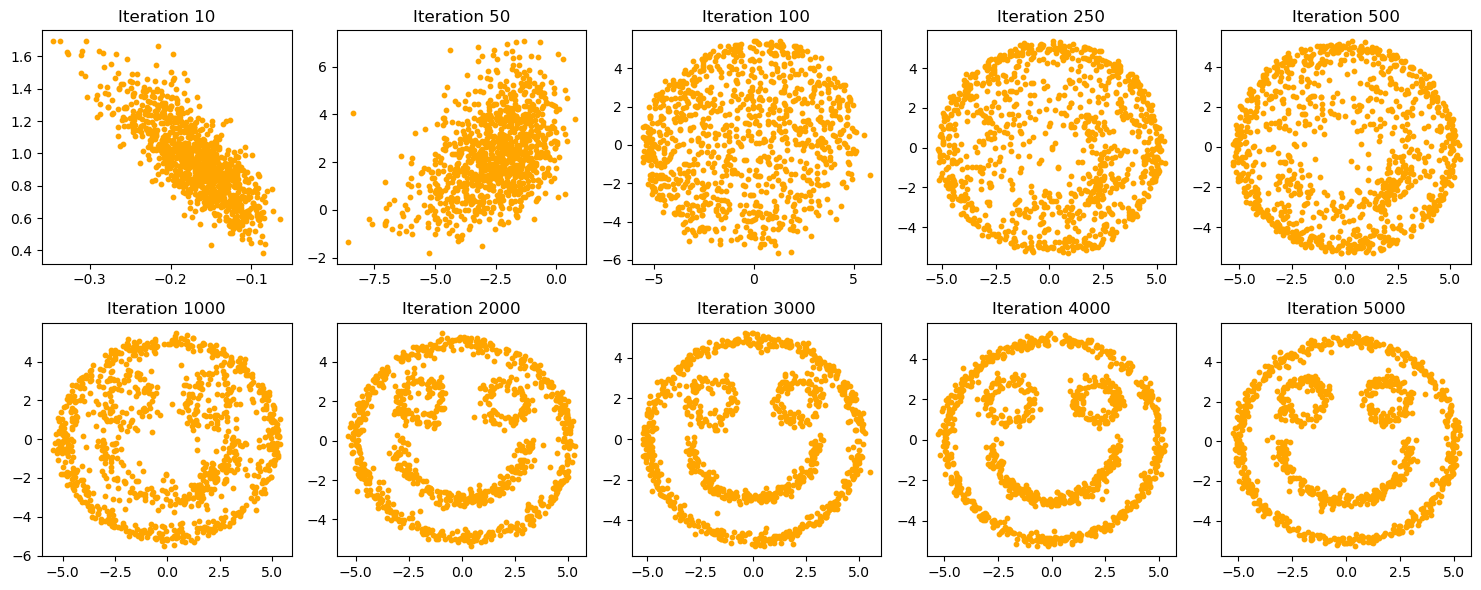

In [9]:
# using temp 0.25
its = [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]

fig, axes = plt.subplots(2, 5, figsize=(15, 6)) 

# Flatten the 2D axes array to 1D to make iteration simple
axes = axes.flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")

plt.tight_layout()

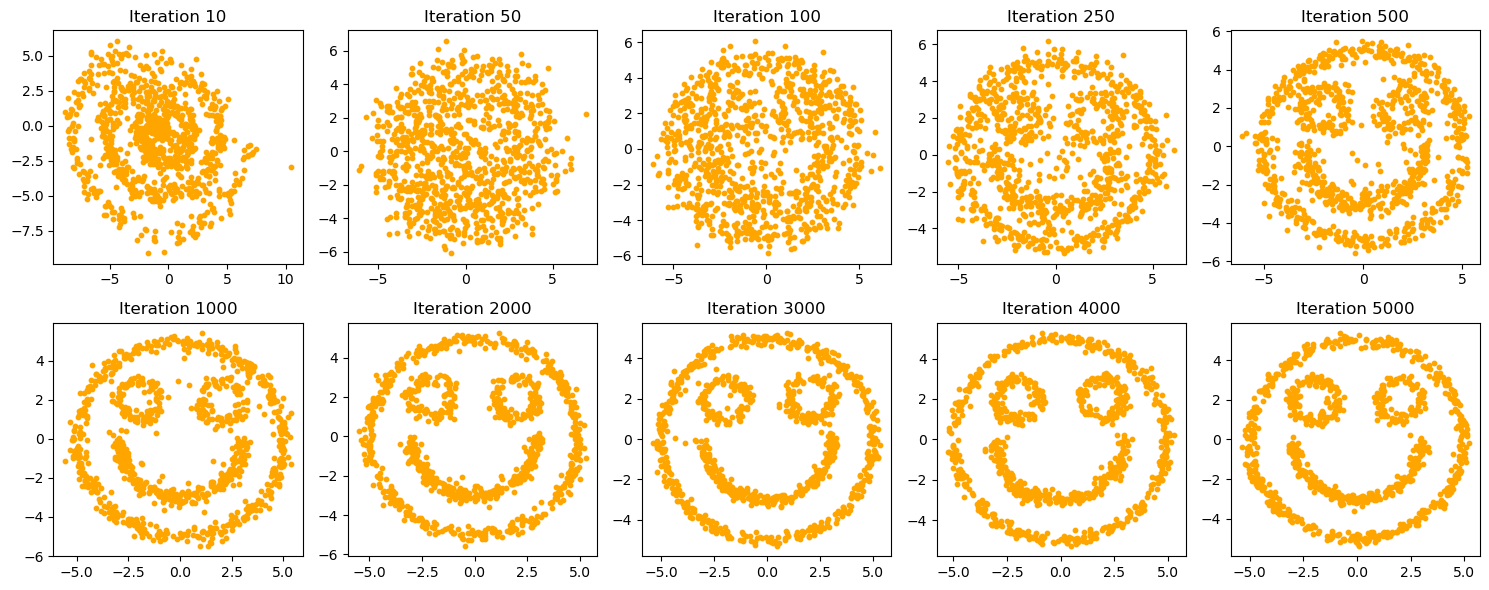

In [397]:
its = [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]

fig, axes = plt.subplots(2, 5, figsize=(15, 6)) 

# Flatten the 2D axes array to 1D to make iteration simple
axes = axes.flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")

plt.tight_layout()

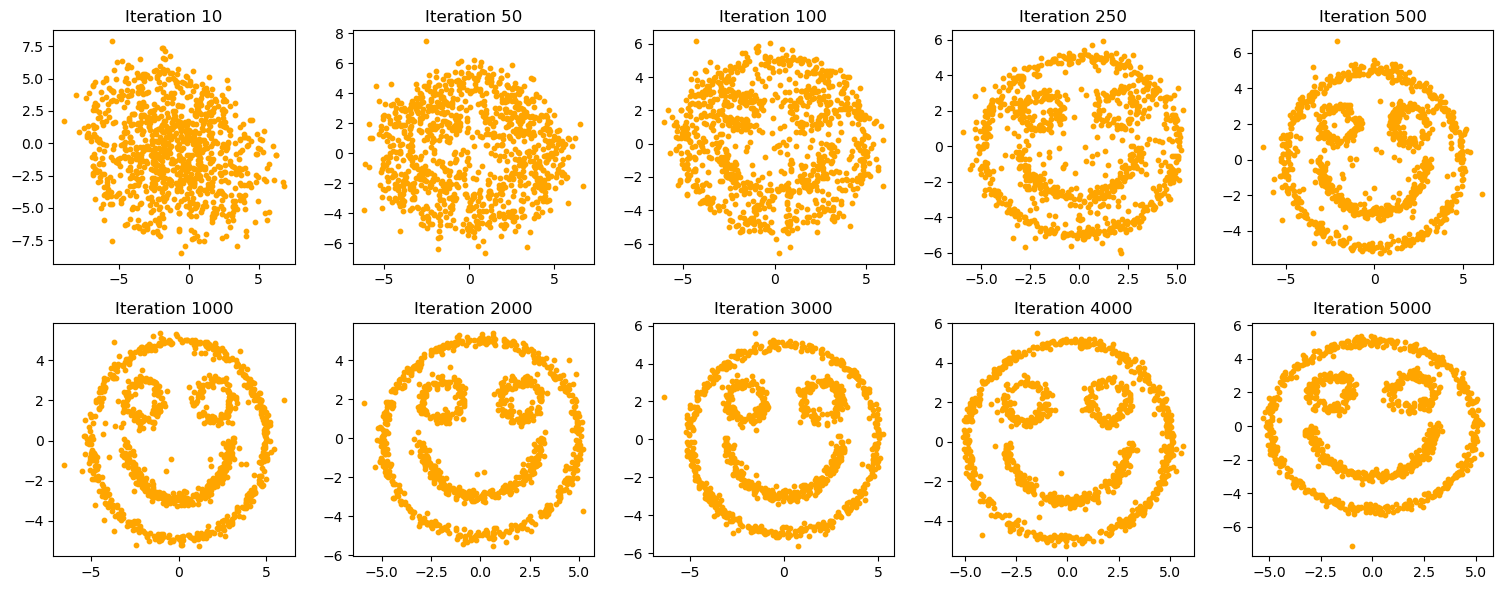

In [377]:
its = [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]

fig, axes = plt.subplots(2, 5, figsize=(15, 6)) 

# Flatten the 2D axes array to 1D to make iteration simple
axes = axes.flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")

plt.tight_layout()

## Generative image generation with Cifar-10 dataset

In [343]:
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

transform = transforms.ToTensor()

class DeerDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.paths = list(Path(folder).glob("*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

deers = DeerDataset("./data/cifar10/train/deer", transform)
loader = DataLoader(
    deers, 
    batch_size=64, 
    shuffle=True, 
    drop_last=True, 
    num_workers=0,
    pin_memory=True       # Speeds up the transfer of data from CPU to GPU
)

In [344]:
len(deers)

5000

In [10]:
deers[9]

tensor([[[0.1490, 0.1608, 0.2235,  ..., 0.0980, 0.1529, 0.1137],
         [0.1647, 0.1922, 0.2196,  ..., 0.1020, 0.1176, 0.1020],
         [0.1333, 0.1843, 0.1647,  ..., 0.1255, 0.1059, 0.0863],
         ...,
         [0.5490, 0.5843, 0.5608,  ..., 0.4510, 0.4392, 0.4471],
         [0.5529, 0.4980, 0.4549,  ..., 0.4627, 0.4431, 0.4471],
         [0.5725, 0.5059, 0.4549,  ..., 0.5020, 0.4745, 0.4824]],

        [[0.2706, 0.2784, 0.3451,  ..., 0.1725, 0.2078, 0.1569],
         [0.2784, 0.3176, 0.3608,  ..., 0.1843, 0.1804, 0.1490],
         [0.2392, 0.3216, 0.3216,  ..., 0.2196, 0.1843, 0.1451],
         ...,
         [0.5647, 0.6000, 0.5765,  ..., 0.4980, 0.4902, 0.4980],
         [0.5686, 0.5137, 0.4667,  ..., 0.5098, 0.4941, 0.4941],
         [0.5843, 0.5137, 0.4627,  ..., 0.5490, 0.5216, 0.5294]],

        [[0.1333, 0.1373, 0.1529,  ..., 0.0863, 0.1373, 0.1059],
         [0.1216, 0.1333, 0.1294,  ..., 0.1098, 0.1255, 0.1098],
         [0.0863, 0.1137, 0.0745,  ..., 0.1294, 0.1098, 0.

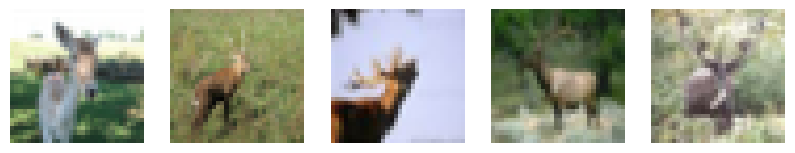

In [13]:
index = np.random.randint(0, len(deers), 5)
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for ax, i in zip(axes, index):
    ax.imshow(deers[i].permute(1, 2, 0))
    ax.axis('off')
    
plt.show()

### First we need to train a VAE to get the latent vector for each deer image


In [152]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self,latent_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.relu3 = nn.ReLU(inplace=True)
        self.conv4 = nn.Conv2d(128, 256, 3, stride=2, padding=1)
        self.relu4 = nn.ReLU(inplace=True)
        self.mu = nn.Linear(4096, latent_dim)
        self.logvar = nn.Linear(4096, latent_dim)

    def forward(self,v):
        v = self.conv1(v)
        v = self.relu1(v)
        v = self.conv2(v)
        v = self.relu2(v)
        v = self.conv3(v)
        v = self.relu3(v)
        v = self.conv4(v)
        v = self.relu4(v)
        v = v.view(v.shape[0], -1)
        return self.mu(v), self.logvar(v)

class Decoder(nn.Module):
    def __init__(self,latent_dim=128):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 128 * 4 * 4)
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),  # (64, 8, 8)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2),   # (32, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 2, stride=2),    # (3, 32, 32)
            nn.Sigmoid()  # pixel values between 0 and 1
        )
    def forward(self, v):
        v = self.linear(v)
        v = v.view(v.shape[0], 128, 4, 4)
        v = self.conv(v)
        return v
    

In [153]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    # core of vae
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std  # sample from N(mu, std)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

In [96]:
def train_vae(num_epochs, loader, model, optimizer):
    model.train()
    model.to(device)
    train_losses = []
    print("Training started")
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        
        for deer in loader:
            x = deer.to(device)
            
            recon, mu, logvar = model(x)  # VAE returns three things
            
            recon_loss = F.mse_loss(recon, x, reduction='sum')
            kl_loss = -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
            loss = recon_loss + kl_loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(loader)
        train_losses.append(avg_loss)
        if epoch % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}] Loss: {avg_loss:.2f}")
        if epoch % 50 == 0:
            print(f"Recon: {recon_loss.item()/64:.1f} | KL: {kl_loss.item()/64:.1f}")
    
    print("Training ended")
    return model, train_losses

In [154]:
from tqdm import tqdm

def train_vae(num_epochs, loader, model, optimizer):
    model.train()
    model.to(device)
    train_losses = []
    print("Training started")
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)
        
        for deer in pbar:
            x = deer.to(device)
            
            recon, mu, logvar = model(x)
            
            recon_loss = F.mse_loss(recon, x, reduction='sum')
            kl_loss = -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
            loss = recon_loss + 0.1 * kl_loss
            
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.2f}")
        
        avg_loss = epoch_loss / len(loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch}/{num_epochs}] Avg Loss: {avg_loss:.2f}")
        if epoch % 50 == 0:
                print(f"Recon: {recon_loss.item()/64:.1f} | KL: {kl_loss.item()/64:.1f}")
    
    print("Training ended")
    return model, train_losses

In [155]:
vae = VAE(latent_dim=512)
optimizer = optim.AdamW(vae.parameters(), lr=0.003)
vae, losses = train_vae(250, loader, vae, optimizer)

Training started


Epoch [0/250] Avg Loss: 6718.97
Recon: 65.4 | KL: 58.0


KeyboardInterrupt: 

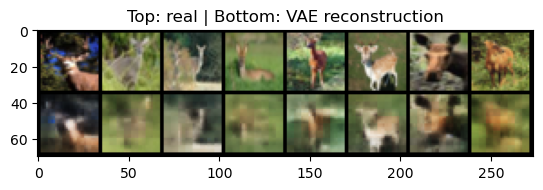

In [100]:
with torch.no_grad():
    real = next(iter(loader))[:8].to(device)
    recon, _, _ = vae(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

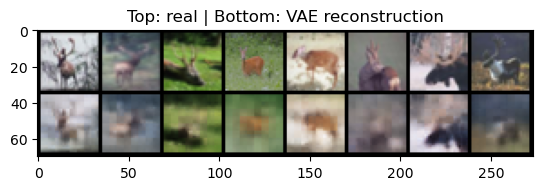

In [101]:
with torch.no_grad():
    real = next(iter(loader))[:8].to(device)
    recon, _, _ = vae(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

In [116]:
vae.eval()
all_latents = []

with torch.no_grad():
    for deer in loader:
        x = deer.to(device)
        mu, logvar = vae.encoder(x)
        z = vae.reparameterize(mu, logvar)  # or just use mu for deterministic encoding
        all_latents.append(z.cpu())

all_latents = torch.cat(all_latents, dim=0)  # (N, 128)

In [118]:
all_latents[0].size()

torch.Size([512])

In [119]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(32, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 512)
        )
    def forward(self, z):
        return self.net(z)

In [223]:
# same as before but with adaptive logits
def softmax(logits, dim):
    logits = logits - logits.max(dim=dim, keepdim=True).values
    exp = torch.exp(logits)
    return exp / exp.sum(dim=dim, keepdim=True)

def compute_V(y_pos, y_neg, T=0.2, eps=1e-8):
    N = y_neg.shape[0]
    points = torch.cat([y_neg, y_pos],dim=0).to(torch.float32)

    dist = torch.cdist(y_neg, points)
    dist[:, :N] += torch.eye(N, device=dist.device) * 1e9 # So that the point you are standing doesn't influence, really important

    mean_dist = dist[dist < 1e5].mean()
    logits = -dist / (mean_dist * T + eps)
    A_row = softmax(logits, dim=1)  # Equivalent to Z normalization, Zq and Zp at the same time
    #A_col = softmax(logits, dim=0)  # normalize each column (target) across particles
    #A = torch.sqrt(A_row * A_col)
    A = A_row
    
    A_neg = A[:, :N]
    A_pos = A[:, N:]

    W_pos = A_pos * A_neg.sum(axis=1, keepdims=True) # k(x,y+) scaled by total neg mass
    W_neg = A_neg * A_pos.sum(axis=1, keepdims=True) # k(x,y-) scaled by total pos mass

    drift_pos = W_pos @ y_pos
    drift_neg = W_neg @ y_neg
    V = drift_pos - (1.2* drift_neg)
    
    return V

def loss_function(generated, y_pos): 
    with torch.no_grad():
        V = compute_V(y_pos, generated)
        frozen_targets = (generated + V).detach().clone()
    return mse(generated, frozen_targets)

In [317]:
len(all_latents)

1152

In [318]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=200, factor=0.5, min_lr=1e-5)
def trainGen(num_epochs, gen, optimizer, gaussian, batch_size = 1152):
    gen.to(device)
    train_losses = []
    print("Training stared")
    
    for epoch in range(num_epochs+1):
        epoch_loss = 0.0
        gen.train()
        optimizer.zero_grad()

        noise_indices = np.random.choice(10000, batch_size, replace=False)
        real_indices = np.random.choice(len(all_latents), batch_size, replace=False)
        gaussian_batch = gaussian[noise_indices]
        truth_batch = all_latents[real_indices].to(device)

        generated = gen(gaussian_batch)
        loss =  loss_function(generated, truth_batch) 
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gen.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss = loss.item()
        train_losses.append(epoch_loss)

        if epoch % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Loss: {epoch_loss:.6f}")
        scheduler.step(epoch_loss)

            
    print("Finished")
    return gen, train_losses
    

In [122]:
gen = Generator()
mse = nn.MSELoss()
optimizer = optim.AdamW(gen.parameters(), lr=0.001)
gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)
gen, losses = trainGen(5000, gen, optimizer, gaussian, 100)

Training stared
Epoch [0/5000], Loss: 0.000220
Epoch [100/5000], Loss: 0.000167
Epoch [200/5000], Loss: 0.000179
Epoch [300/5000], Loss: 0.000192
Epoch [400/5000], Loss: 0.000190
Epoch [500/5000], Loss: 0.000182
Epoch [600/5000], Loss: 0.000190
Epoch [700/5000], Loss: 0.000216
Epoch [800/5000], Loss: 0.000231
Epoch [900/5000], Loss: 0.000217
Epoch [1000/5000], Loss: 0.000207
Epoch [1100/5000], Loss: 0.000212
Epoch [1200/5000], Loss: 0.000207
Epoch [1300/5000], Loss: 0.000224
Epoch [1400/5000], Loss: 0.000213
Epoch [1500/5000], Loss: 0.000223
Epoch [1600/5000], Loss: 0.000221
Epoch [1700/5000], Loss: 0.000229
Epoch [1800/5000], Loss: 0.000232
Epoch [1900/5000], Loss: 0.000223
Epoch [2000/5000], Loss: 0.000218
Epoch [2100/5000], Loss: 0.000225
Epoch [2200/5000], Loss: 0.000222
Epoch [2300/5000], Loss: 0.000232
Epoch [2400/5000], Loss: 0.000238
Epoch [2500/5000], Loss: 0.000248
Epoch [2600/5000], Loss: 0.000235
Epoch [2700/5000], Loss: 0.000242
Epoch [2800/5000], Loss: 0.000234
Epoch [290

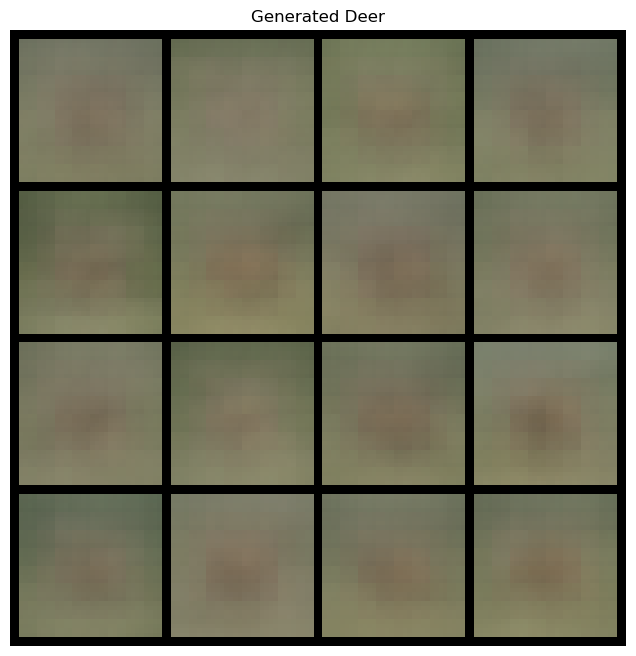

In [126]:
gen.eval()
vae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    images = vae.decoder(latents)

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

## Now using STL-10 dataset

In [ ]:
from __future__ import print_function

import sys
import os, sys, tarfile, errno
import numpy as np
import matplotlib.pyplot as plt
    
if sys.version_info >= (3, 0, 0):
    import urllib.request as urllib # ugly but works
else:
    import urllib

try:
    from imageio import imsave
except:
    from scipy.misc import imsave

print(sys.version_info) 

# image shape
HEIGHT = 96
WIDTH = 96
DEPTH = 3

# size of a single image in bytes
SIZE = HEIGHT * WIDTH * DEPTH

# path to the directory with the data
DATA_DIR = './data'

# url of the binary data
DATA_URL = 'http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz'

# path to the binary train file with image data
DATA_PATH = './data/stl10_binary/train_X.bin'

# path to the binary train file with labels
LABEL_PATH = './data/stl10_binary/train_y.bin'

def read_labels(path_to_labels):
    """
    :param path_to_labels: path to the binary file containing labels from the STL-10 dataset
    :return: an array containing the labels
    """
    with open(path_to_labels, 'rb') as f:
        labels = np.fromfile(f, dtype=np.uint8)
        return labels


def read_all_images(path_to_data):
    """
    :param path_to_data: the file containing the binary images from the STL-10 dataset
    :return: an array containing all the images
    """

    with open(path_to_data, 'rb') as f:
        # read whole file in uint8 chunks
        everything = np.fromfile(f, dtype=np.uint8)

        # We force the data into 3x96x96 chunks, since the
        # images are stored in "column-major order", meaning
        # that "the first 96*96 values are the red channel,
        # the next 96*96 are green, and the last are blue."
        # The -1 is since the size of the pictures depends
        # on the input file, and this way numpy determines
        # the size on its own.

        images = np.reshape(everything, (-1, 3, 96, 96))

        # Now transpose the images into a standard image format
        # readable by, for example, matplotlib.imshow
        # You might want to comment this line or reverse the shuffle
        # if you will use a learning algorithm like CNN, since they like
        # their channels separated.
        images = np.transpose(images, (0, 3, 2, 1))
        return images


def read_single_image(image_file):
    """
    CAREFUL! - this method uses a file as input instead of the path - so the
    position of the reader will be remembered outside of context of this method.
    :param image_file: the open file containing the images
    :return: a single image
    """
    # read a single image, count determines the number of uint8's to read
    image = np.fromfile(image_file, dtype=np.uint8, count=SIZE)
    # force into image matrix
    image = np.reshape(image, (3, 96, 96))
    # transpose to standard format
    # You might want to comment this line or reverse the shuffle
    # if you will use a learning algorithm like CNN, since they like
    # their channels separated.
    image = np.transpose(image, (2, 1, 0))
    return image


def plot_image(image):
    """
    :param image: the image to be plotted in a 3-D matrix format
    :return: None
    """
    plt.imshow(image)
    plt.show()

def save_image(image, name):
    imsave("%s.png" % name, image, format="png")

def download_and_extract():
    """
    Download and extract the STL-10 dataset
    :return: None
    """
    dest_directory = DATA_DIR
    if not os.path.exists(dest_directory):
        os.makedirs(dest_directory)
    filename = DATA_URL.split('/')[-1]
    filepath = os.path.join(dest_directory, filename)
    if not os.path.exists(filepath):
        def _progress(count, block_size, total_size):
            sys.stdout.write('\rDownloading %s %.2f%%' % (filename,
                float(count * block_size) / float(total_size) * 100.0))
            sys.stdout.flush()
        filepath, _ = urllib.urlretrieve(DATA_URL, filepath, reporthook=_progress)
        print('Downloaded', filename)
        tarfile.open(filepath, 'r:gz').extractall(dest_directory)

def save_images(images, labels):
    print("Saving images to disk")
    i = 0
    for image in images:
        label = labels[i]
        directory = './img/' + str(label) + '/'
        try:
            os.makedirs(directory, exist_ok=True)
        except OSError as exc:
            if exc.errno == errno.EEXIST:
                pass
        filename = directory + str(i)
        # print(filename)
        save_image(image, filename)
        i = i+1
    
if __name__ == "__main__":
    # download data if needed
    download_and_extract()

    # test to check if the image is read correctly
    with open(DATA_PATH) as f:
        image = read_single_image(f)
        plot_image(image)

    # test to check if the whole dataset is read correctly
    images = read_all_images(DATA_PATH)
    print(images.shape)

    labels = read_labels(LABEL_PATH)
    print(labels.shape)

    # save images to disk
    save_images(images, labels)

In [ ]:
DATA_PATH = './data/stl10_binary/test_X.bin'
LABEL_PATH = './data/stl10_binary/test_y.bin'
images = read_all_images(DATA_PATH)
labels = read_labels(LABEL_PATH)
save_images(images, labels)

In [351]:
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
deers = DeerDataset("./data/stl10/deers", transform)
loader = DataLoader(
    deers, 
    batch_size=128, 
    shuffle=True, 
    drop_last=True, 
    num_workers=0,
    pin_memory=True       # Speeds up the transfer of data from CPU to GPU
)

In [346]:
len(deers)

1263

In [136]:
deers[0].size()

torch.Size([3, 96, 96])

In [137]:
len(deers)

1263

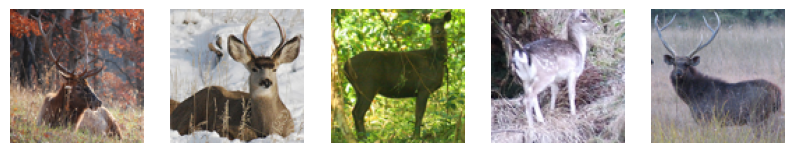

In [133]:
index = np.random.randint(0, len(deers), 5)
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for ax, i in zip(axes, index):
    ax.imshow(deers[i].permute(1, 2, 0))
    ax.axis('off')
    
plt.show()

In [157]:
class Encoder(nn.Module):
    def __init__(self,latent_dim=1024):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=96, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(96, 192, 3, stride=2, padding=1)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv3 = nn.Conv2d(192, 384, 3, stride=2, padding=1)
        self.relu3 = nn.ReLU(inplace=True)
        self.conv4 = nn.Conv2d(384, 768, 3, stride=2, padding=1)
        self.relu4 = nn.ReLU(inplace=True)
        self.conv5 = nn.Conv2d(768, 1536, 3, stride=2, padding=1)
        self.relu5 = nn.ReLU(inplace=True)
        self.mu = nn.Linear(1536, latent_dim)
        self.logvar = nn.Linear(1536, latent_dim)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self,v):
        v = self.conv1(v)
        v = self.relu1(v)
        v = self.conv2(v)
        v = self.relu2(v)
        v = self.conv3(v)
        v = self.relu3(v)
        v = self.conv4(v)
        v = self.relu4(v)
        v = self.conv5(v)
        v = self.relu5(v)
        v = self.avgpool(v) # Result is (Batch, 1536, 1, 1)
        v = v.view(v.shape[0], -1) # Result is (Batch, 1536)
        return self.mu(v), self.logvar(v)

import torch.nn as nn

class Decoder(nn.Module):
    def __init__(self, latent_dim=1024):
        super().__init__()
        # 1. Project back to the shape of the Encoder's final output (1536 channels * 6 * 6)
        self.linear = nn.Linear(latent_dim, 1536 * 6 * 6)
        
        # 2. Upsample back to 96x96
        # We use kernel_size=4, stride=2, padding=1 to exactly double the resolution
        self.conv = nn.Sequential(
            # Input: (1536, 6, 6) -> Output: (768, 12, 12)
            nn.ConvTranspose2d(1536, 768, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            
            # Input: (768, 12, 12) -> Output: (384, 24, 24)
            nn.ConvTranspose2d(768, 384, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            
            # Input: (384, 24, 24) -> Output: (192, 48, 48)
            nn.ConvTranspose2d(384, 192, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            
            # Input: (192, 48, 48) -> Output: (96, 96, 96)
            nn.ConvTranspose2d(192, 96, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            
            # Final reconstruction to 3 channels (RGB)
            # No stride here because we are already at 96x96
            nn.Conv2d(96, 3, kernel_size=3, padding=1),
            nn.Sigmoid() 
        )

    def forward(self, v):
        v = self.linear(v)
        # Reshape into (batch, channels, height, width)
        v = v.view(v.shape[0], 1536, 6, 6)
        v = self.conv(v)
        return v
        
class VAE(nn.Module):
    def __init__(self, latent_dim=1024):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    # core of vae
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std  # sample from N(mu, std)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

In [193]:
import torch
import torch.nn as nn

class VanillaVAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2)
        )
        
        self.fc_mu = nn.Linear(256 * 6 * 6, latent_dim)
        self.fc_var = nn.Linear(256 * 6 * 6, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, 256 * 6 * 6)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        features = self.encoder(x)
        features = features.view(features.size(0), -1)
        mu = self.fc_mu(features)
        logvar = self.fc_var(features)
        
        z = self.reparameterize(mu, logvar)
        
        z = self.decoder_input(z)
        z = z.view(z.size(0), 256, 6, 6)
        recon = self.decoder(z)
        
        return recon, mu, logvar

In [197]:
def train_vae(num_epochs, loader, model, optimizer):
    #patience=10, min_delta=0.001
    model.train()
    model.to(device)
    train_losses = []
    
    # Early stopping variables
    best_loss = float('inf')
    epochs_no_improve = 0
    
    print("Training started")
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        
        for x in pbar: # Renamed 'deer' to 'x' for clarity
            x = x.to(device)
            
            recon, mu, logvar = model(x)
            
            recon_loss = F.mse_loss(recon, x, reduction='sum')
            kl_loss = -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
            loss = recon_loss + 0.05 * kl_loss
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.2f}")
        
        avg_loss = epoch_loss / len(loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] Avg Loss: {avg_loss:.4f}")
        '''
        # --- Early Stopping Logic ---
        if avg_loss < best_loss - min_delta:
            best_loss = avg_loss
            epochs_no_improve = 0
            # Optional: save the best model here
            torch.save(model.state_dict(), "best_vae.pth")
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break
        '''
    print("Training ended")
    return model, train_losses

In [198]:
vae = VanillaVAE(latent_dim=256)
optimizer = optim.AdamW(vae.parameters(), lr=0.002)
vae, losses = train_vae(500, loader, vae, optimizer)

Training started


Epoch [1/500] Avg Loss: 591963.5990


Epoch [2/500] Avg Loss: 162877.0174


Epoch [3/500] Avg Loss: 137858.3247


Epoch [4/500] Avg Loss: 125043.5799


...

Epoch [496/500] Avg Loss: 14641.5940


Epoch [497/500] Avg Loss: 14641.1823


Epoch [498/500] Avg Loss: 14769.2170


Epoch [499/500] Avg Loss: 15036.3675


Epoch [500/500] Avg Loss: 14648.9201
Training ended


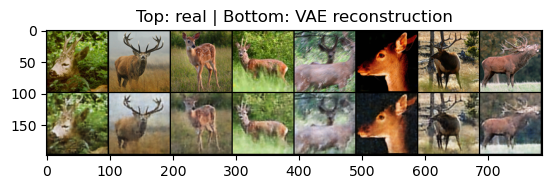

In [199]:
with torch.no_grad():
    real = next(iter(loader))[:8].to(device)
    recon, _, _ = vae(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

In [189]:
all_latents = []
vae.eval()
with torch.no_grad():
    for deer in loader:
        x = deer.to(device)
        recon, mu, logvar = vae(x)
        z = vae.reparameterize(mu, logvar)
        all_latents.append(z.cpu())

all_latents = torch.cat(all_latents, dim=0) 

In [191]:
all_latents[0]

tensor([-1.7532e+00, -1.5771e+00,  1.1817e-01, -4.3580e-01, -2.3598e+00,
        -5.0866e-01, -5.0676e-01,  1.8221e+00,  1.2523e+00, -1.8600e+00,
         1.3752e+00,  5.1544e-01,  4.3776e-01, -4.4198e-01, -2.1337e-01,
        -6.7140e-02, -9.6158e-01,  4.9019e-01, -1.2603e+00, -1.2259e-01,
         1.8803e+00,  5.9589e-01, -1.0630e+00,  1.0649e+00, -1.0079e+00,
         4.1257e-01,  2.1559e+00, -3.5871e-01,  9.2687e-01,  1.7135e+00,
        -1.5108e+00,  6.5749e-01,  9.0141e-01,  7.7727e-01, -8.4452e-01,
         1.1004e+00,  3.6761e-01,  2.0250e-01,  3.7692e-01,  2.0174e-01,
        -8.2197e-01, -2.0746e-01, -6.6486e-02,  7.6792e-01,  1.1745e+00,
        -1.0062e+00,  4.4160e-01,  1.9609e+00, -1.2276e+00,  1.9504e-01,
         1.0797e+00, -1.7462e+00, -1.6197e-01, -1.6268e+00,  1.7033e+00,
        -1.6616e-01, -2.8428e+00, -1.2212e+00, -6.7302e-01, -1.8210e+00,
         5.6907e-01,  1.8740e+00,  6.8250e-01,  2.8481e-01,  1.0279e-01,
         4.7988e-01, -3.0011e-01, -1.5866e-01,  4.1

In [185]:
class Generator(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(32, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, latent_dim)
        )
    def forward(self, z):
        return self.net(z)

In [340]:
# same as before but with adaptive logits
def softmax(logits, dim):
    logits = logits - logits.max(dim=dim, keepdim=True).values
    exp = torch.exp(logits)
    return exp / exp.sum(dim=dim, keepdim=True)

def compute_V(y_pos, y_neg, T=0.25, eps=1e-8):
    N = y_neg.shape[0]
    
    dist_pos = torch.cdist(y_neg, y_pos)
    dist_neg = torch.cdist(y_neg, y_neg)
    dist_neg += torch.eye(N, device=dist_neg.device) * 1e6
    
    mean_dist = (dist_pos.mean() + dist_neg[dist_neg < 1e5].mean()) / 2
    
    logit_pos = -dist_pos / (mean_dist * T + eps)
    logit_neg = -dist_neg / (mean_dist * T + eps)
    
    # normalize separately
    W_pos = softmax(logit_pos, dim=1)
    W_neg = softmax(logit_neg, dim=1)
    
    drift_pos = W_pos @ y_pos
    drift_neg = W_neg @ y_neg
    V = drift_pos - drift_neg
    return V

def loss_function(generated, y_pos): 
    with torch.no_grad():
        V = compute_V(y_pos, generated)
        frozen_targets = (generated + V).detach().clone()
    return mse(generated, frozen_targets)

In [320]:
gen = Generator(latent_dim=256)
mse = nn.MSELoss()
optimizer = optim.AdamW(gen.parameters(), lr=0.0003)
gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)
gen, losses = trainGen(8000, gen, optimizer, gaussian, 100)

Training stared
Epoch [0/8000], Loss: 0.036219
Epoch [100/8000], Loss: 0.005883
Epoch [200/8000], Loss: 0.009346
Epoch [300/8000], Loss: 0.007921
Epoch [400/8000], Loss: 0.008491
Epoch [500/8000], Loss: 0.006822
Epoch [600/8000], Loss: 0.008137
Epoch [700/8000], Loss: 0.005743
Epoch [800/8000], Loss: 0.006743
Epoch [900/8000], Loss: 0.010059
Epoch [1000/8000], Loss: 0.011289
Epoch [1100/8000], Loss: 0.009097
Epoch [1200/8000], Loss: 0.009316
Epoch [1300/8000], Loss: 0.007496
Epoch [1400/8000], Loss: 0.010175
Epoch [1500/8000], Loss: 0.006719
Epoch [1600/8000], Loss: 0.011822
Epoch [1700/8000], Loss: 0.009562
Epoch [1800/8000], Loss: 0.009514
Epoch [1900/8000], Loss: 0.007005
Epoch [2000/8000], Loss: 0.007171
Epoch [2100/8000], Loss: 0.007966
Epoch [2200/8000], Loss: 0.006707
Epoch [2300/8000], Loss: 0.007514
Epoch [2400/8000], Loss: 0.009100
Epoch [2500/8000], Loss: 0.009532
Epoch [2600/8000], Loss: 0.008160
Epoch [2700/8000], Loss: 0.009986
Epoch [2800/8000], Loss: 0.008467
Epoch [290

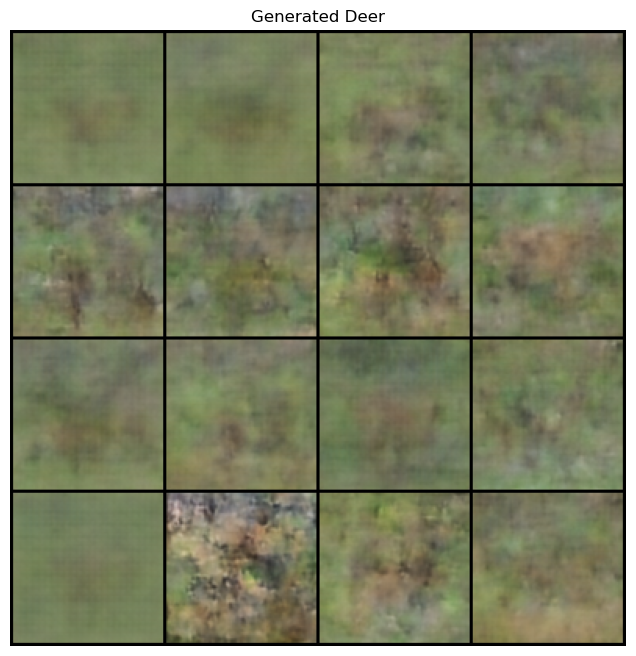

In [321]:
gen.eval()
vae.eval()
with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise) 
    x = vae.decoder_input(latents)
    x = x.view(-1, 256, 6, 6)
    images = vae.decoder(x)

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

In [364]:
light_vae = VanillaVAE(latent_dim=128)
optimizer = optim.AdamW(vae.parameters(), lr=0.002)
light_vae, losses = train_vae(500, loader, vae, optimizer)

Training started


KeyboardInterrupt: 

In [ ]:
light_vae.to(device)
with torch.no_grad():
    real = next(iter(loader))[:8].to(device)
    recon, _, _ = light_vae(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

In [356]:
all_latents = []
light_vae.eval()
with torch.no_grad():
    for _ in range(5):
        for deer in loader:
            x = deer.to(device)
            _, mu, _ = light_vae(x)  # forward returns (recon, mu, logvar)
            all_latents.append(mu.cpu())  # use mu directly, not reparameterize

all_latents = torch.cat(all_latents, dim=0)
print(all_latents.shape)

torch.Size([5760, 256])


In [341]:
light_gen = Generator(latent_dim=128)
mse = nn.MSELoss()
optimizer = optim.AdamW(gen.parameters(), lr=0.0001)
gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)
light_gen, losses = trainGen(3000, gen, optimizer, gaussian, 100)

Training stared
Epoch [0/3000], Loss: 0.046264
Epoch [100/3000], Loss: 0.011067
Epoch [200/3000], Loss: 0.010997
Epoch [300/3000], Loss: 0.008476
Epoch [400/3000], Loss: 0.009336
Epoch [500/3000], Loss: 0.012570
Epoch [600/3000], Loss: 0.014652
Epoch [700/3000], Loss: 0.010942
Epoch [800/3000], Loss: 0.008609
Epoch [900/3000], Loss: 0.008150
Epoch [1000/3000], Loss: 0.014004
Epoch [1100/3000], Loss: 0.013351
Epoch [1200/3000], Loss: 0.010674
Epoch [1300/3000], Loss: 0.010271
Epoch [1400/3000], Loss: 0.010071
Epoch [1500/3000], Loss: 0.013194
Epoch [1600/3000], Loss: 0.011579
Epoch [1700/3000], Loss: 0.006801
Epoch [1800/3000], Loss: 0.010701
Epoch [1900/3000], Loss: 0.012129
Epoch [2000/3000], Loss: 0.011041
Epoch [2100/3000], Loss: 0.011262
Epoch [2200/3000], Loss: 0.009813
Epoch [2300/3000], Loss: 0.012457
Epoch [2400/3000], Loss: 0.010200
Epoch [2500/3000], Loss: 0.010444
Epoch [2600/3000], Loss: 0.009451
Epoch [2700/3000], Loss: 0.012571
Epoch [2800/3000], Loss: 0.014599
Epoch [290

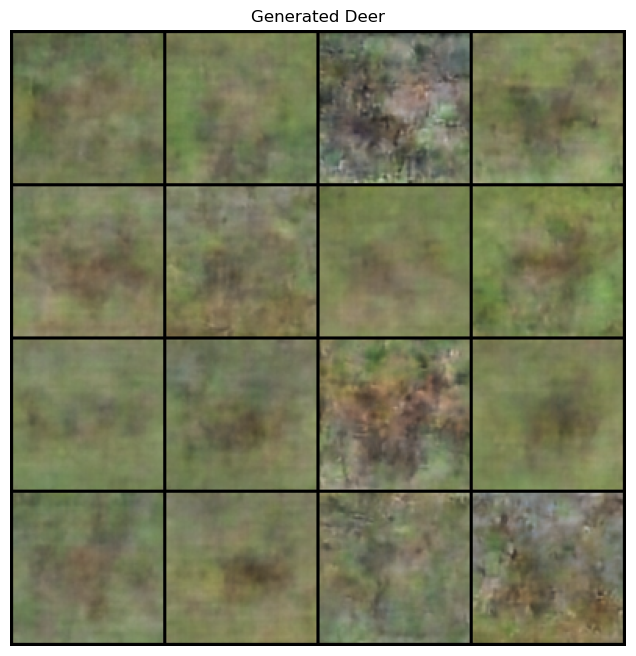

In [352]:
light_gen.to(device)
light_vae.to(device)
light_gen.eval()
light_vae.eval()
with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = light_gen(noise) 
    x = light_vae.decoder_input(latents)
    x = x.view(-1, 256, 6, 6)
    images = light_vae.decoder(x)

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()